In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('../words.txt', 'r').read().splitlines()
words[:8]

['abakus',
 'abandon',
 'abazja',
 'abażur',
 'abażurek',
 'abdukcja',
 'abduktor',
 'abdykacja']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [4]:
block_size = 3  # context size

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [5]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([400292, 3]) torch.Size([400292])
torch.Size([50134, 3]) torch.Size([50134])
torch.Size([50015, 3]) torch.Size([50015])


#### batch norm layer  
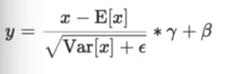

#### tanh  
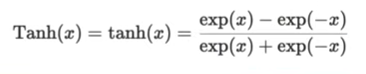

In [6]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)     # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

n_emb = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_emb), generator=g)
layers = [
    Linear(n_emb * block_size, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3     # 5/3 for tanh

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

47274


In [7]:
max_steps = 300000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000:
        break

      0/ 300000: 3.5319


### forward pass activations statistics after 1k epochs

layer 1 (      Tanh): mean -0.01, std 0.76, saturated: 19.38%
layer 3 (      Tanh): mean -0.02, std 0.73, saturated: 13.81%
layer 5 (      Tanh): mean -0.01, std 0.72, saturated: 11.16%
layer 7 (      Tanh): mean +0.00, std 0.72, saturated: 11.44%
layer 9 (      Tanh): mean +0.02, std 0.73, saturated: 11.78%


/tmp/ipykernel_4773/268958625.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

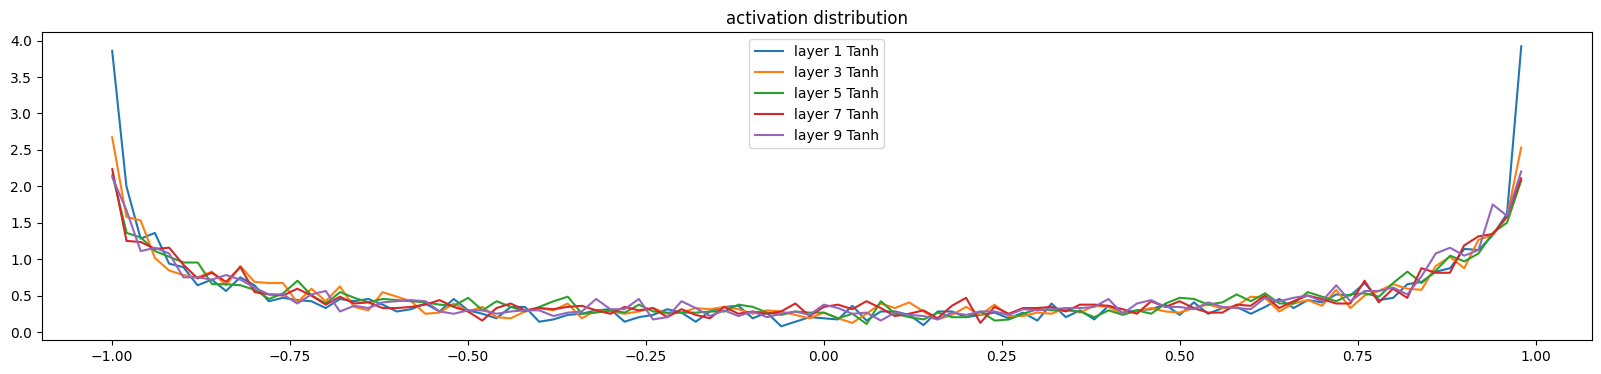

In [8]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends);
plt.title('activation distribution')

with gain = 1 instead of 5/3 it would be  
  
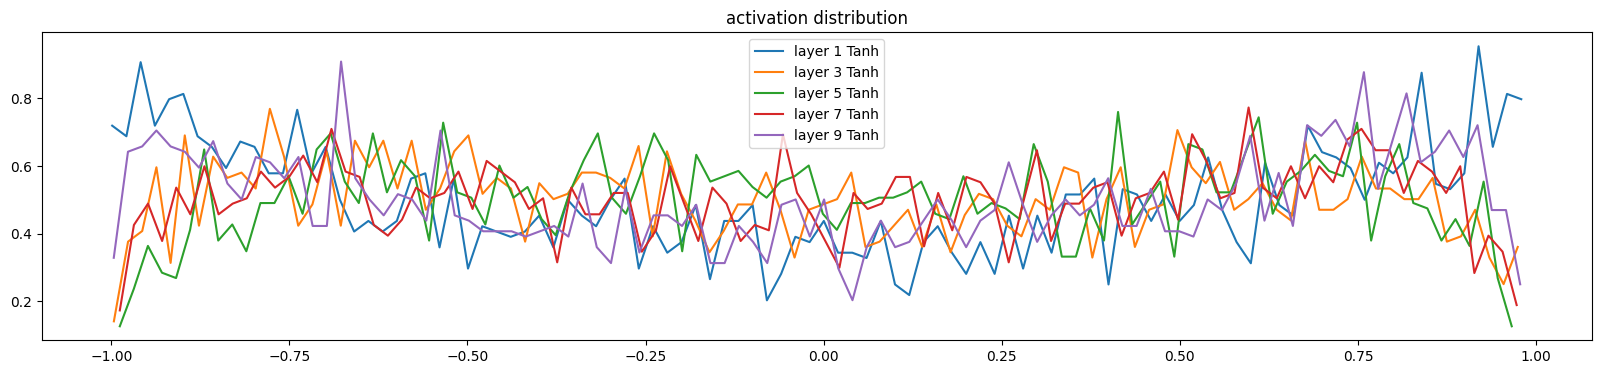

with gain=2  
  
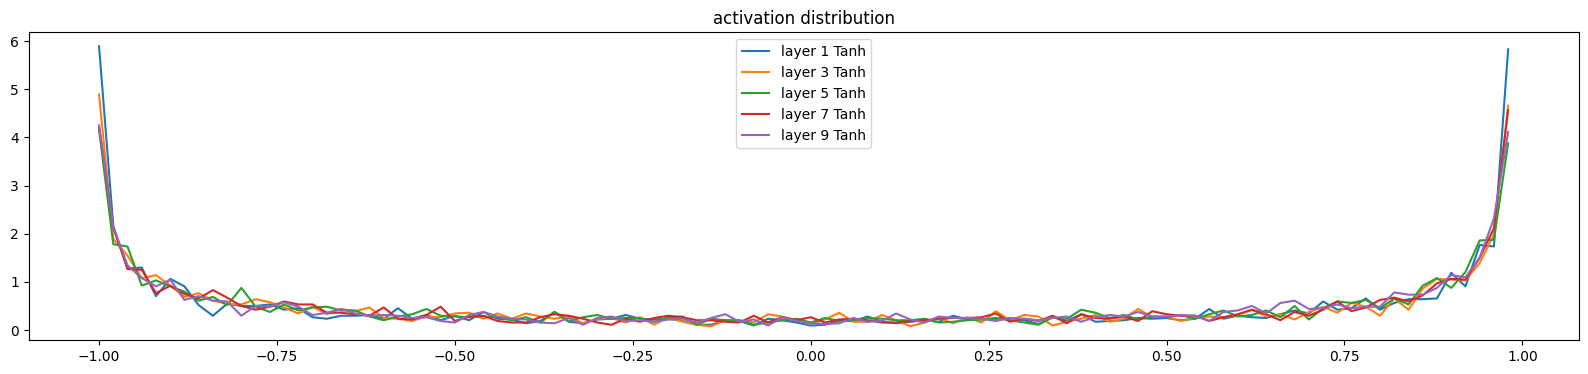

after every linear layer variation is 0.5x smaller (because tanh saturates the tails).  
gain=5/3 reduces this effect

### backward pass gradient statistics after 1 epoch

layer 1 (      Tanh): mean +0.000126, std 0.0043
layer 3 (      Tanh): mean +0.000168, std 0.0040
layer 5 (      Tanh): mean -0.000065, std 0.0036
layer 7 (      Tanh): mean +0.000008, std 0.0031
layer 9 (      Tanh): mean +0.000024, std 0.0024


Text(0.5, 1.0, 'gradient distribution')

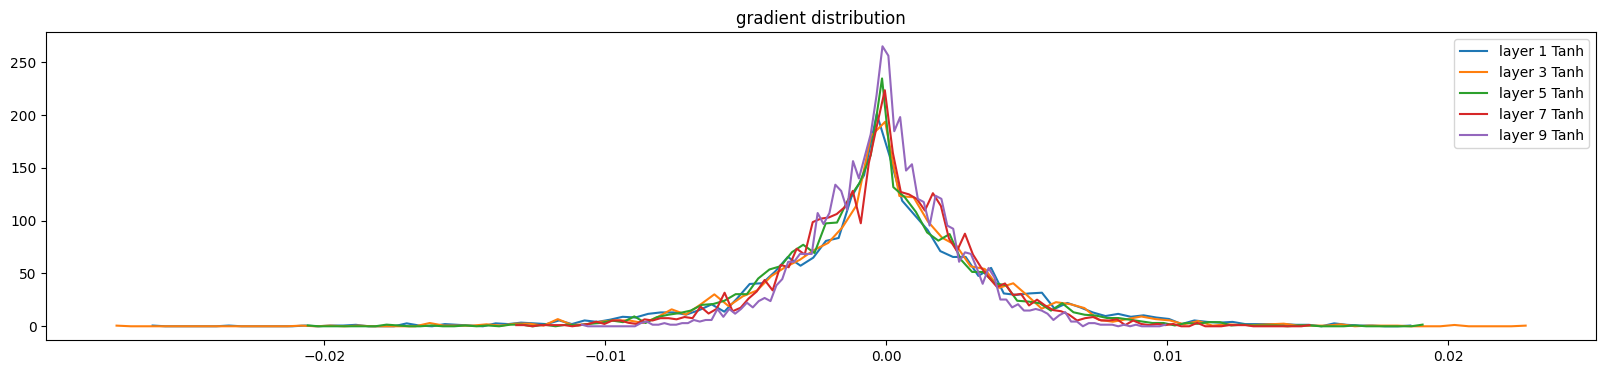

In [9]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.6f, std %.4f' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends);
plt.title('gradient distribution')

- gradient layers should overlap
- a big peak means dead neurons
- histogram shouldn't be to wide (>>1)
- should be simmetrical

with gain=0.5  
  
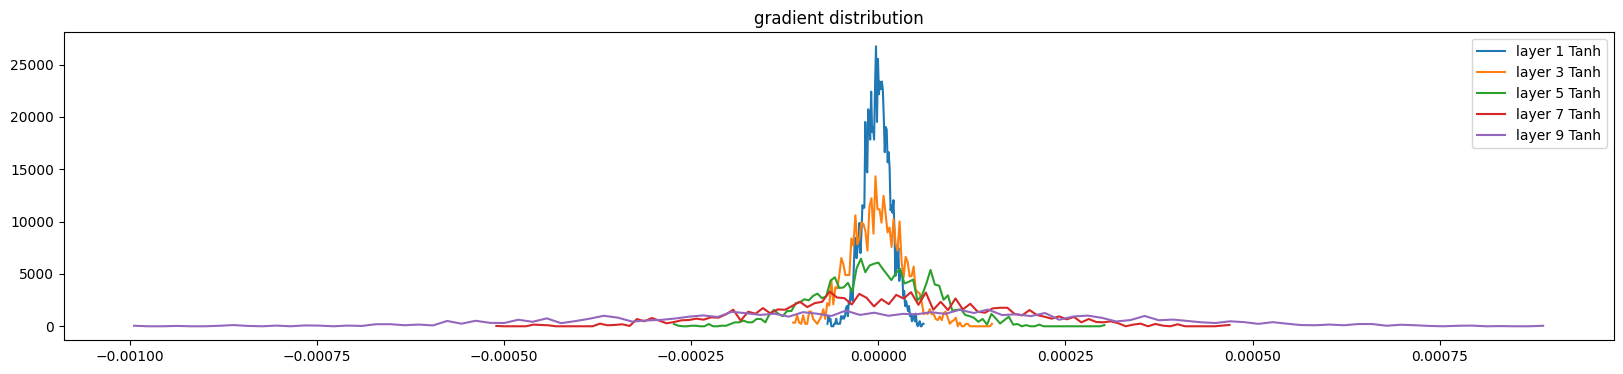

with gain=1  
  
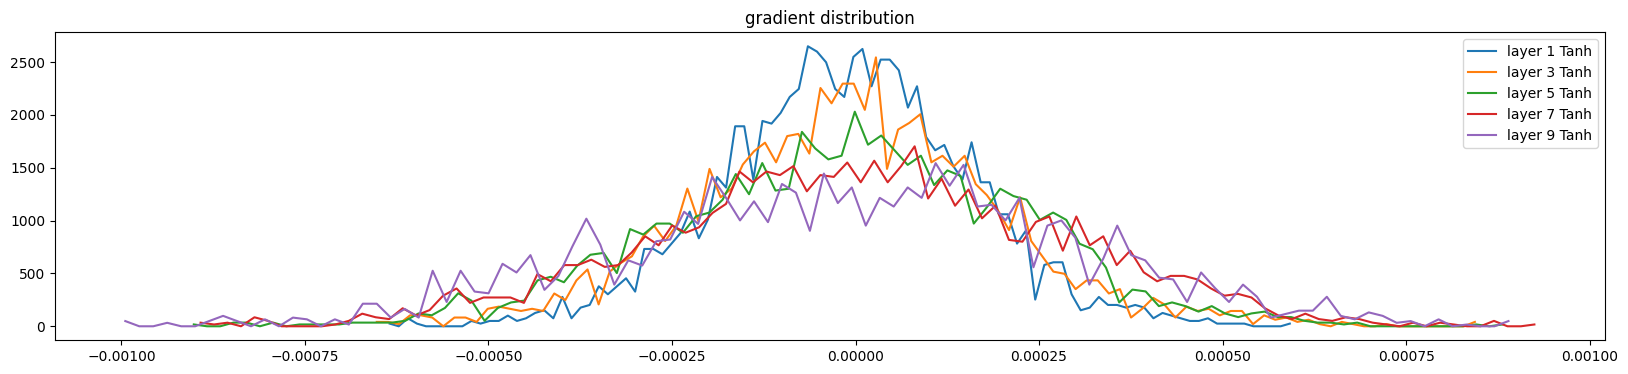

with gain=3  
  
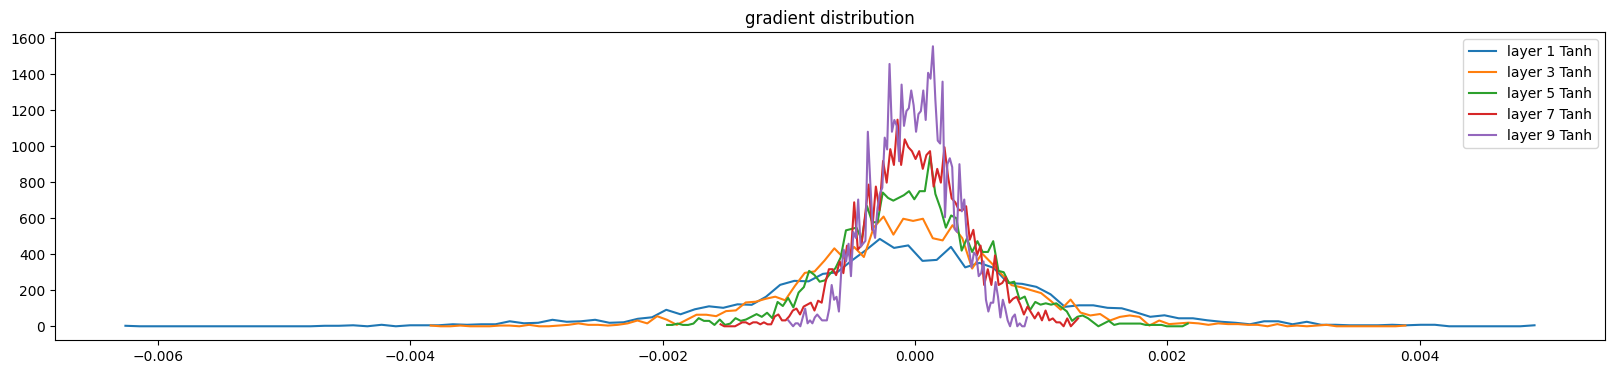

### weights gradient distribution (it stabilizes)

after 1 epoch  
  
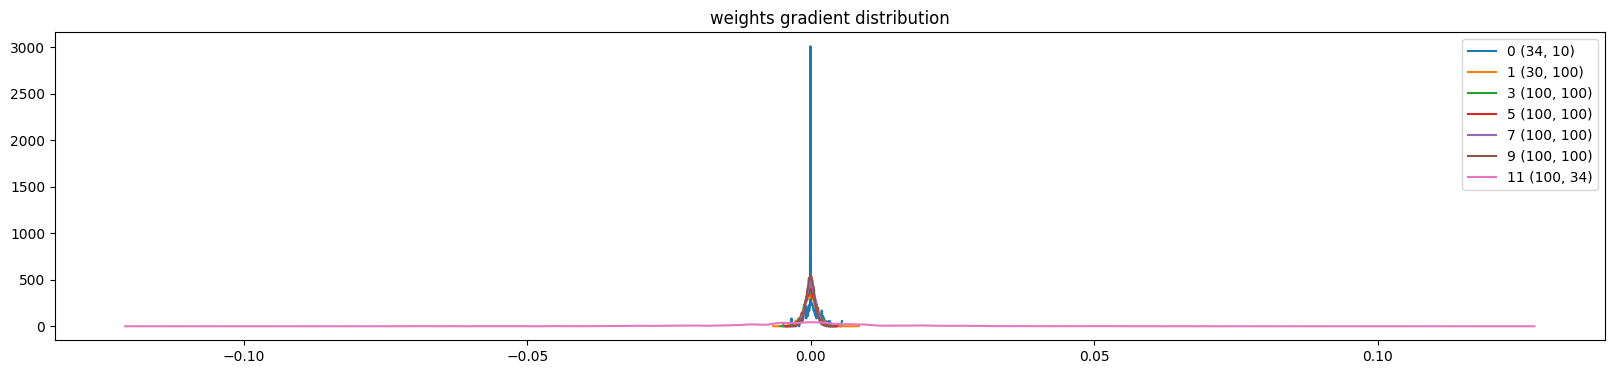

after 1k epochs

weight   (34, 10) | mean +0.000371 | std 1.390791e-02 | grad:data ratio 1.412931e-02
weight  (30, 100) | mean -0.000157 | std 1.329804e-02 | grad:data ratio 4.312273e-02
weight (100, 100) | mean +0.000126 | std 1.052170e-02 | grad:data ratio 6.178231e-02
weight (100, 100) | mean +0.000107 | std 9.266285e-03 | grad:data ratio 5.482700e-02
weight (100, 100) | mean +0.000049 | std 8.247547e-03 | grad:data ratio 4.879220e-02
weight (100, 100) | mean -0.000116 | std 5.990939e-03 | grad:data ratio 3.534467e-02
weight  (100, 34) | mean -0.000000 | std 1.955033e-02 | grad:data ratio 2.462052e-01


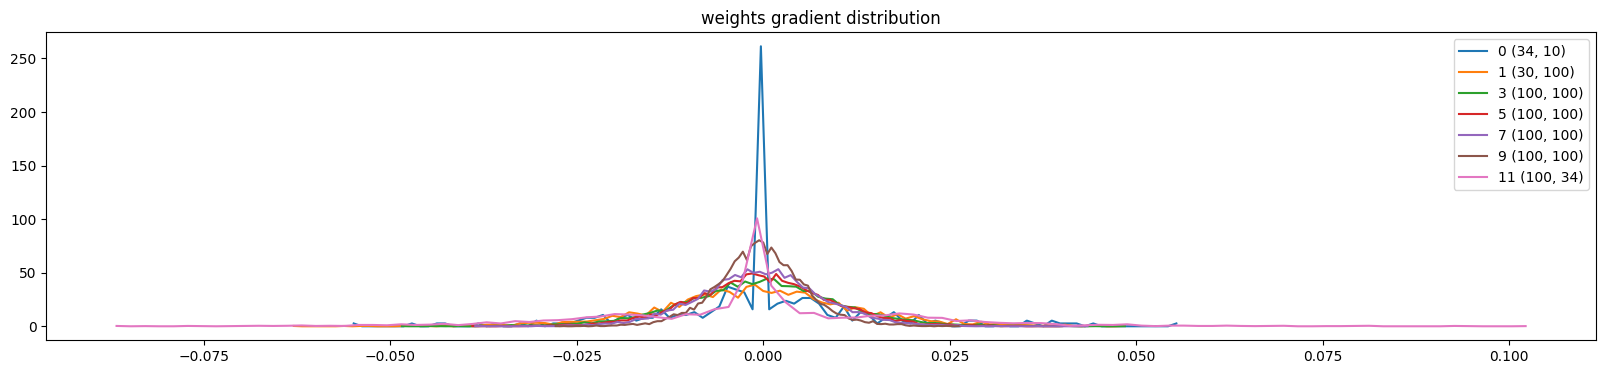

In [10]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');


### update-to-parameter ratio

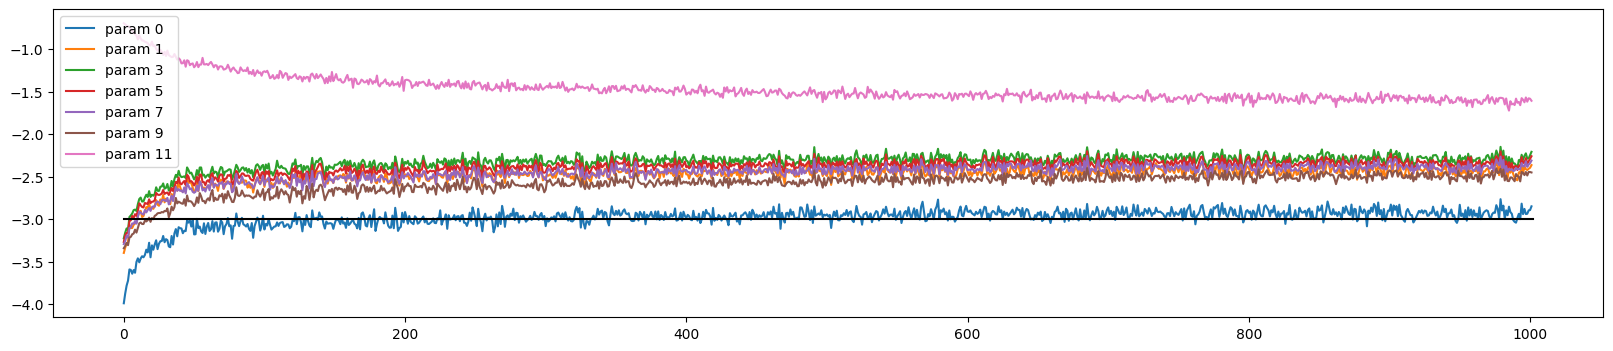

In [11]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

the 11th layer stands out because it was artfifically shrunk down when we multipliesd it by 0.1

if parameters are below the black line, it means that the net doesn't learn fast enough  
e.g for lr=0.01  
  
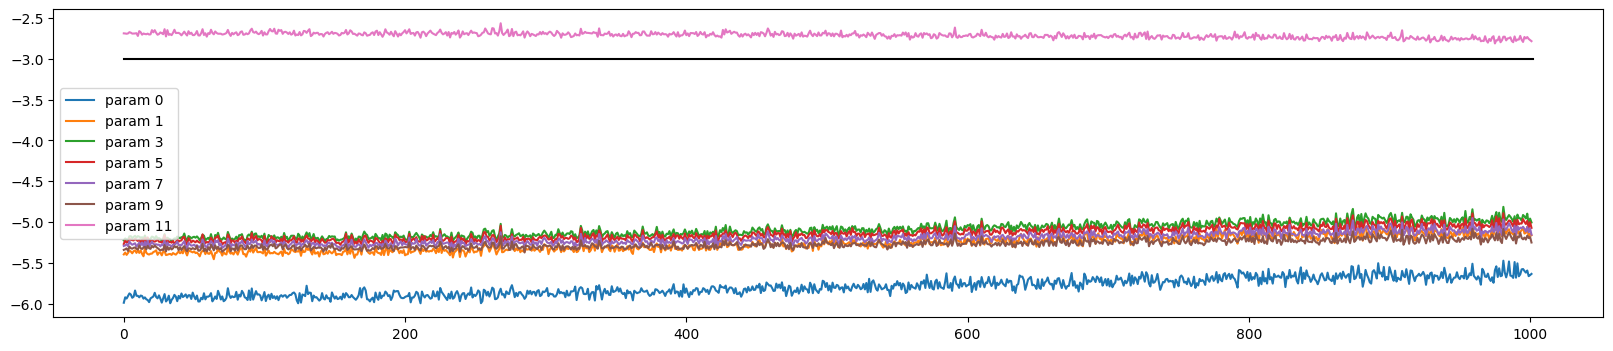

##### by plotting the things above you can see if something is wrong, for example if you forgot to divide the weights by fan_in**0.5

without batch norm you have to adjust the parameters very carefully

### bath norm

In [ ]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)     # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

n_emb = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_emb), generator=g)
layers = [
    Linear(n_emb * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    #layers[-1].weight *= 0.1
    layers[-1].gamma *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3     # 5/3 for tanh

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

48342


In [21]:
max_steps = 300000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    emb = C[Xb]                             # chars embedded into vectors
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000:
        break

      0/ 300000: 3.5316


layer 2 (      Tanh): mean +0.00, std 0.63, saturated: 3.22%
layer 5 (      Tanh): mean -0.00, std 0.63, saturated: 2.38%
layer 8 (      Tanh): mean -0.00, std 0.63, saturated: 2.72%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 2.25%
layer 14 (      Tanh): mean +0.01, std 0.63, saturated: 2.81%


Text(0.5, 1.0, 'activation distribution')

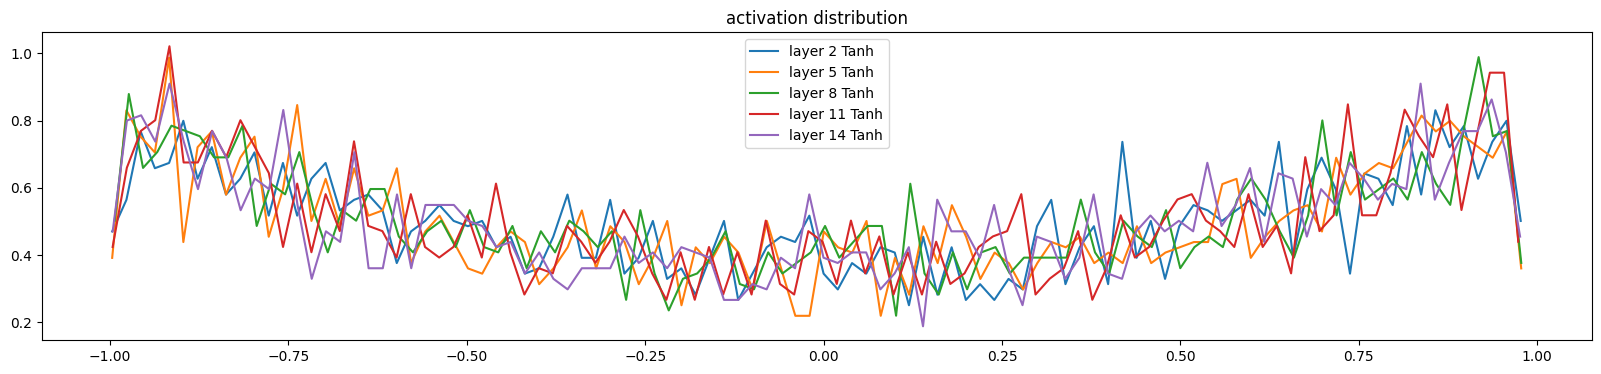

In [22]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 0.0029
layer 5 (      Tanh): mean -0.000000, std 0.0028
layer 8 (      Tanh): mean -0.000000, std 0.0025
layer 11 (      Tanh): mean -0.000000, std 0.0024
layer 14 (      Tanh): mean +0.000000, std 0.0022


Text(0.5, 1.0, 'gradient distribution')

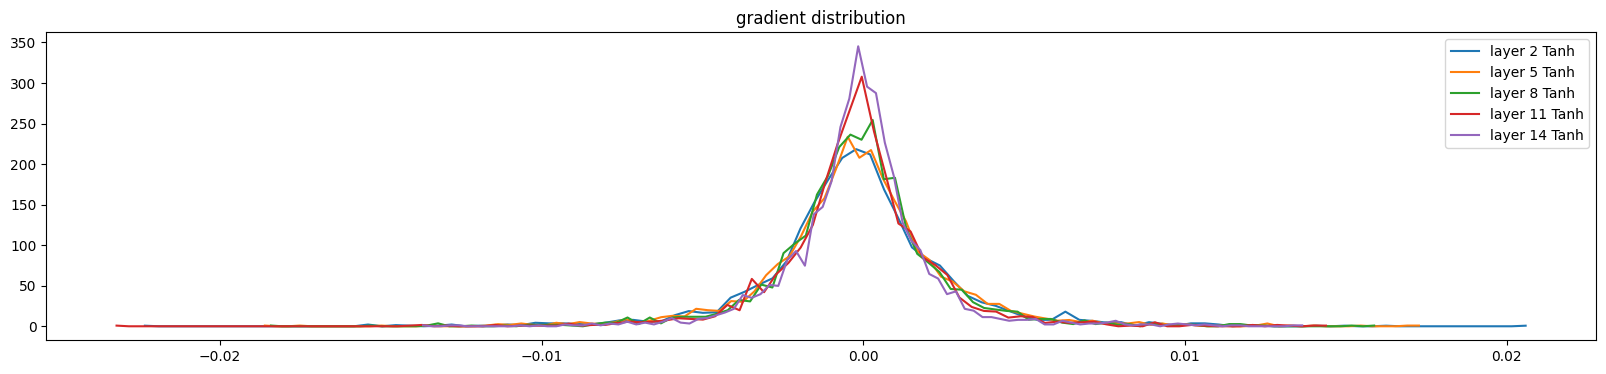

In [23]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.6f, std %.4f' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends);
plt.title('gradient distribution')

weight   (34, 10) | mean -0.000000 | std 6.420545e-03 | grad:data ratio 6.527408e-03
weight  (30, 100) | mean +0.000017 | std 1.331373e-03 | grad:data ratio 7.933592e-04
weight (100, 100) | mean +0.000009 | std 6.527847e-04 | grad:data ratio 3.896907e-04
weight (100, 100) | mean +0.000011 | std 5.570118e-04 | grad:data ratio 3.346747e-04
weight (100, 100) | mean +0.000002 | std 5.234733e-04 | grad:data ratio 3.141877e-04
weight (100, 100) | mean -0.000001 | std 4.905748e-04 | grad:data ratio 2.933645e-04
weight  (100, 34) | mean +0.000017 | std 7.569423e-04 | grad:data ratio 4.572638e-04


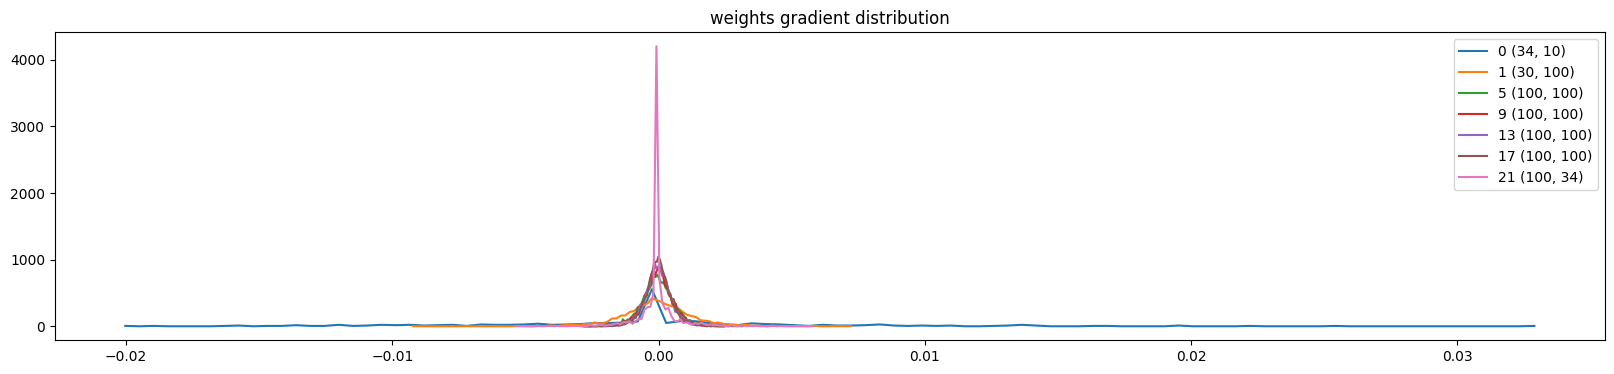

In [24]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');


^ it's scaled inversely

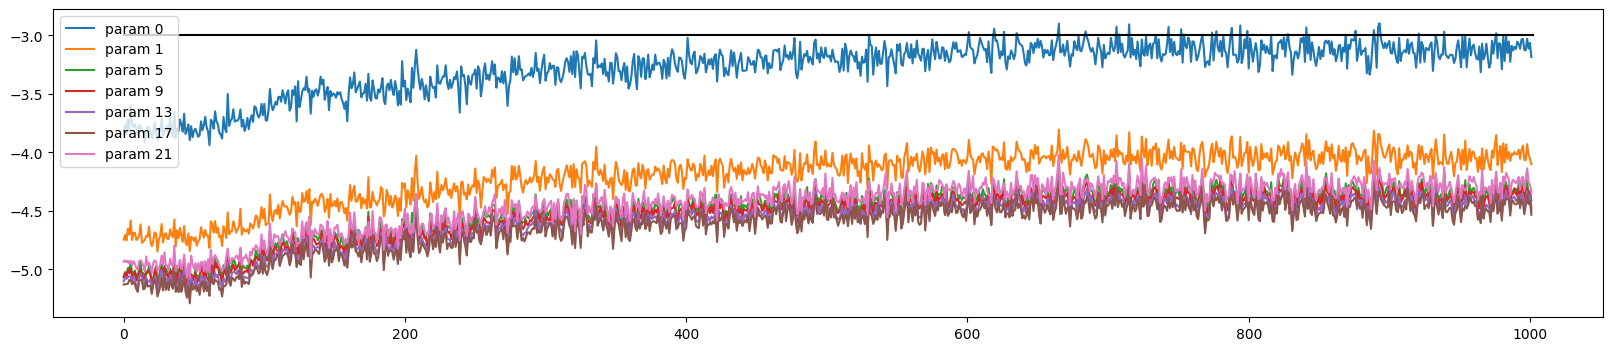

In [25]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

with batch norm, when we pass a wrong gain, like 0.2, activation distribution and gradient distribution won't change but update-to-parameter ratio will change, so you have to change the learning rate  
also weights gradient distribution will scale inversely 
batch norm makes mistakes less infuential  
also we can ommit the ` / fan_in**0.5` but it's not advised